# **COPPER FUTURES**

In [ ]:
import pandas as pd
import glob
import os

# Folder path
folder_path = '/content/drive/MyDrive/Copper '

# File pattern for all CSV or Excel files
file_pattern_csv = os.path.join(folder_path, '*.csv')
file_pattern_xlsx = os.path.join(folder_path, '*.xlsx')

# Read all CSV files
all_files_csv = glob.glob(file_pattern_csv)
all_files_xlsx = glob.glob(file_pattern_xlsx)

# Function to read each file (csv or xlsx) into DataFrame
def read_file(file):
    if file.endswith('.csv'):
        return pd.read_csv(file)
    else:
        return pd.read_excel(file)

# Read and concatenate all files into one DataFrame
df_list = [read_file(f) for f in all_files_csv + all_files_xlsx]
df = pd.concat(df_list, ignore_index=True)

# Preview columns
print("Columns found:", df.columns)

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=False, errors='coerce')

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Check for missing dates and fill if necessary
date_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max())
df = df.set_index('Date').reindex(date_range).rename_axis('Date').reset_index()

# Forward fill missing values if any (price columns etc.)
df.fillna(method='ffill', inplace=True)

# Now df contains merged data with continuous dates
# You can save or return df for analysis
df.to_csv('merged_mcx_copper.csv', index=False)
print("Merged data saved to merged_mcx_copper.csv")


Columns found: Index(['Instrument Type', 'Date', 'Segment', 'Commodity',
       'Traded Contract(Lots)', 'Total Value (Lacs)',
       'Avg Daily Turnover (Lacs)', 'Premium Value (Lacs)'],
      dtype='object')
Merged data saved to merged_mcx_copper.csv


<ipython-input-43-0bca83802875>:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df.head()

,Date,Instrument Type,Segment,Commodity,Traded Contract(Lots),Total Value (Lacs),Avg Daily Turnover (Lacs),Premium Value (Lacs)
0,2010-01-01,FUTCOM,NaN,NaN,3603.0,12388.86,NaN,-
1,2010-01-02,FUTCOM,NaN,NaN,2226.0,7666.67,NaN,-
2,2010-01-03,FUTCOM,NaN,NaN,2226.0,7666.67,NaN,-
3,2010-01-04,FUTCOM,NaN,NaN,97331.0,338302.92,NaN,-
4,2010-01-05,FUTCOM,NaN,NaN,88363.0,306060.54,NaN,-


In [ ]:
# Drop the unnecessary columns
df.drop(columns=['Avg Daily Turnover (Lacs)', 'Premium Value (Lacs)', 'Instrument Type', 'Segment', 'Commodity'], inplace=True)

# Preview the cleaned DataFrame
print(df.head())


        Date  Traded Contract(Lots)  Total Value (Lacs)
0 2010-01-01                 3603.0            12388.86
1 2010-01-02                 2226.0             7666.67
2 2010-01-03                 2226.0             7666.67
3 2010-01-04                97331.0           338302.92
4 2010-01-05                88363.0           306060.54


Before June 18, 2019:
The standard copper futures contract had a lot size of 1 MT (1000 kg).

On or after June 18, 2019:
The lot size increased to 2.5 MT (2500 kg).

In [ ]:
import pandas as pd

# Convert Date to datetime if not already
df['Date'] = pd.to_datetime(df['Date'])

# Define a function to assign lot size based on date
def get_lot_size(date):
    if date < pd.Timestamp('2019-07-01'):
        return 1000  # 1 MT in kg
    else:
        return 2500  # 2.5 MT in kg

# Apply the function to create a new lot_size_kg column
df['lot_size_kg'] = df['Date'].apply(get_lot_size)

# Drop rows with zero contracts to avoid division errors
df = df[df['Traded Contract(Lots)'] > 0]

# Calculate approximate average price per kg for each day using correct lot size
df['Avg_Price'] = (df['Total Value (Lacs)'] * 100000) / (df['Traded Contract(Lots)'] * df['lot_size_kg'])

print(df[['Date', 'lot_size_kg', 'Avg_Price']].head())


        Date  lot_size_kg   Avg_Price
0 2010-01-01         1000  343.848460
1 2010-01-02         1000  344.414645
2 2010-01-03         1000  344.414645
3 2010-01-04         1000  347.579826
4 2010-01-05         1000  346.367303


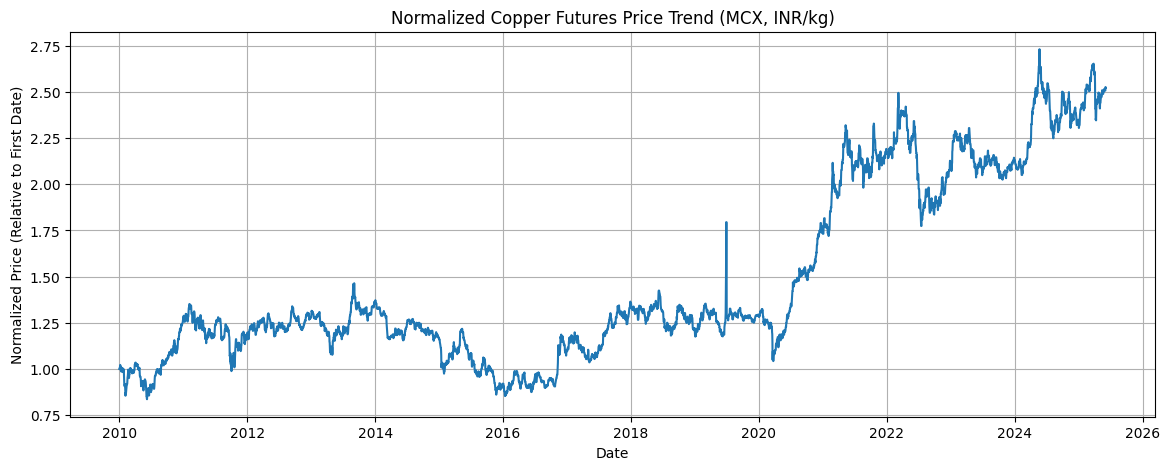

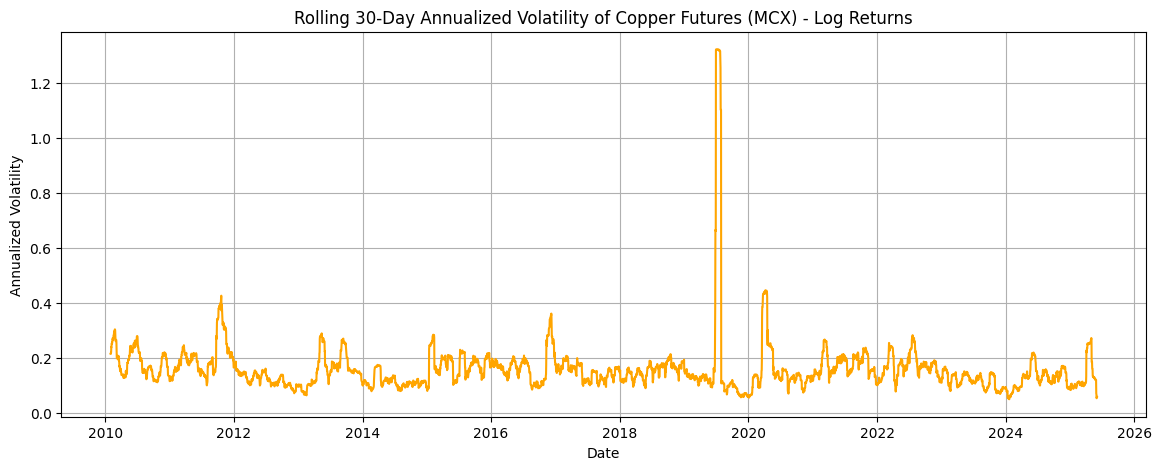

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure 'Date' column is datetime type and data is sorted by date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Calculate log returns (natural log of ratio of consecutive Avg_Price values)
df['Log_Returns'] = np.log(df['Avg_Price'] / df['Avg_Price'].shift(1))

# Calculate average number of unique trading days per year in the dataset
df['Year'] = df['Date'].dt.year
avg_trading_days = df.groupby('Year')['Date'].nunique().mean()

# Calculate rolling 30-day standard deviation of log returns
rolling_std_30d = df['Log_Returns'].rolling(window=30).std()

# Annualize the volatility by multiplying rolling std dev by sqrt of avg trading days per year
df['Volatility_30d'] = rolling_std_30d * np.sqrt(avg_trading_days)

# Normalize price series by dividing each price by the first price for relative trend visualization
df['Normalized_Price'] = df['Avg_Price'] / df['Avg_Price'].iloc[0]

# Plot normalized price trend over time
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='Date', y='Normalized_Price')
plt.title('Normalized Copper Futures Price Trend (MCX, INR/kg)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Relative to First Date)')
plt.grid(True)
plt.show()

# Plot rolling 30-day annualized volatility over time
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='Date', y='Volatility_30d', color='orange')
plt.title('Rolling 30-Day Annualized Volatility of Copper Futures (MCX) - Log Returns')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.grid(True)
plt.show()


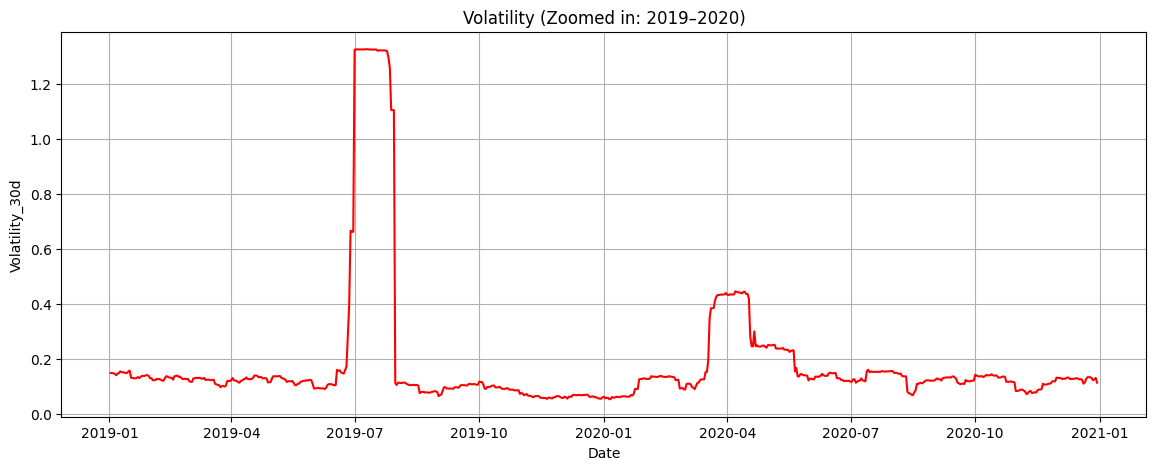

In [ ]:
mask = (df['Date'] > '2019-01-01') & (df['Date'] < '2020-12-31')
plt.figure(figsize=(14, 5))
sns.lineplot(data=df[mask], x='Date', y='Volatility_30d', color='red')
plt.title('Volatility (Zoomed in: 2019–2020)')
plt.grid(True)
plt.show()


[*********************100%***********************]  1 of 1 completed


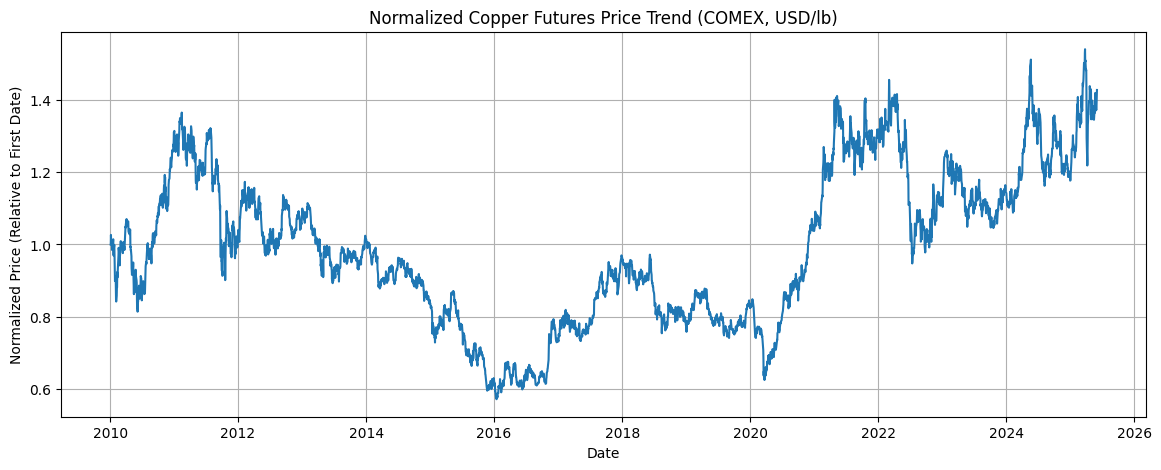

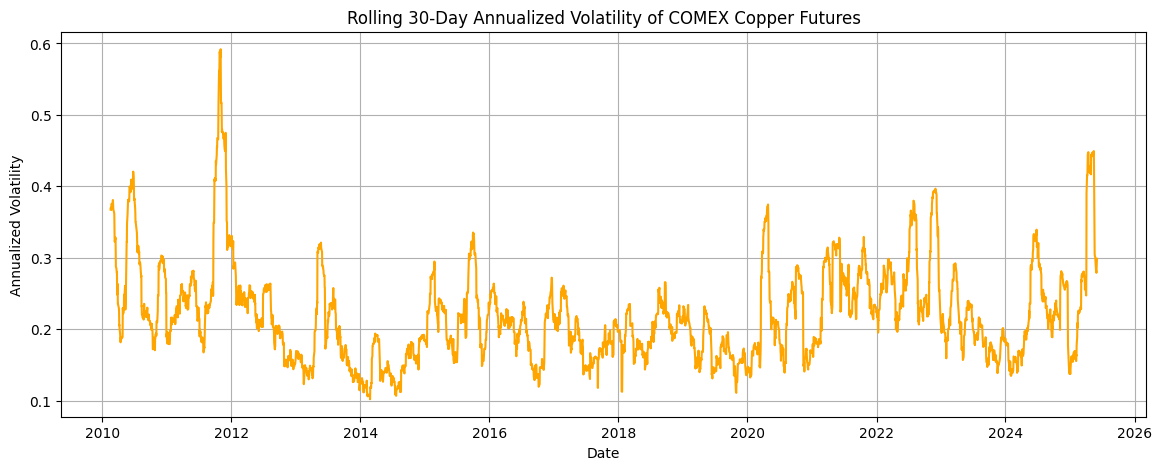

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download COMEX Copper futures data from Jan 1, 2010 to June 3, 2025
copper_comex = yf.download('HG=F', start='2010-01-01', end='2025-06-03', auto_adjust=False)

# Reset index to move 'Date' from index to a column
copper_comex.reset_index(inplace=True)

# Extract Close prices as a Series
close_prices = copper_comex['Close']
if isinstance(close_prices, pd.DataFrame):
    close_prices = close_prices.squeeze()

# Build the DataFrame with just Date and Close price
df_comex = pd.DataFrame({
    'Date': copper_comex['Date'],
    'Close_Price': close_prices
})

# Drop rows with missing Close prices to avoid NaNs in calculations
df_comex.dropna(inplace=True)

# Calculate log returns (natural log of price relative change)
df_comex['Log_Returns'] = np.log(df_comex['Close_Price'] / df_comex['Close_Price'].shift(1))

# Calculate rolling 30-day standard deviation of log returns (volatility)
rolling_std_30d = df_comex['Log_Returns'].rolling(window=30).std()

# Annualize the volatility by multiplying by sqrt of trading days in a year (252)
df_comex['Volatility_30d'] = rolling_std_30d * np.sqrt(252)

# Normalize prices by dividing by the first available price, to show relative trend from start date
df_comex['Normalized_Price'] = df_comex['Close_Price'] / df_comex['Close_Price'].iloc[0]

# Plot normalized price trend
plt.figure(figsize=(14, 5))
sns.lineplot(x='Date', y='Normalized_Price', data=df_comex)
plt.title('Normalized Copper Futures Price Trend (COMEX, USD/lb)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Relative to First Date)')
plt.grid(True)
plt.show()

# Plot rolling 30-day annualized volatility
plt.figure(figsize=(14, 5))
sns.lineplot(x='Date', y='Volatility_30d', data=df_comex, color='orange')
plt.title('Rolling 30-Day Annualized Volatility of COMEX Copper Futures')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.grid(True)
plt.show()


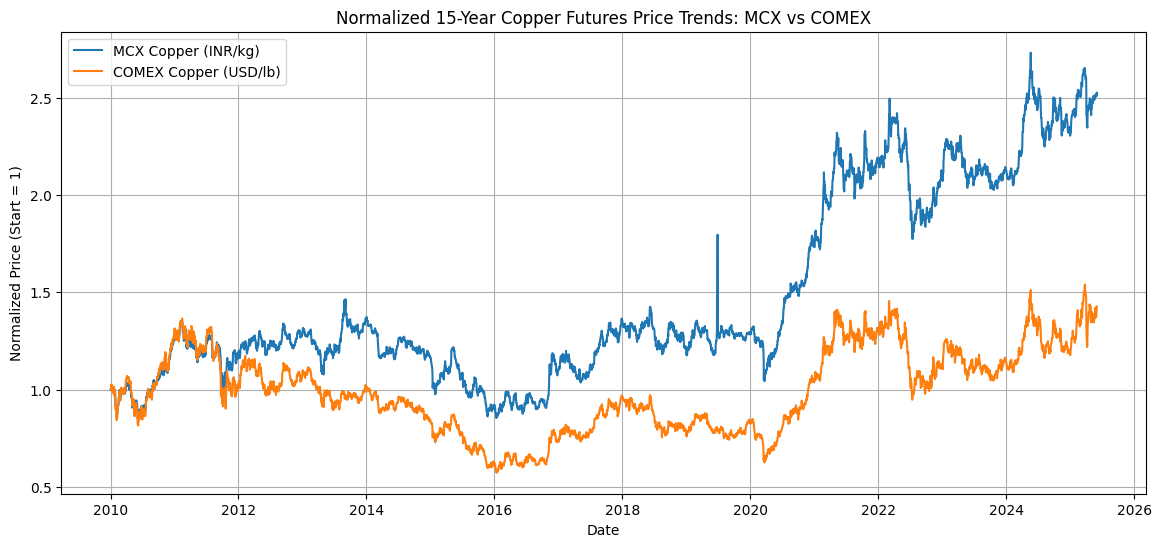

In [ ]:
# First, make sure both dfs have 'Date' as datetime and sorted
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df_comex['Date'] = pd.to_datetime(df_comex['Date'])
df_comex = df_comex.sort_values('Date')

# Normalize prices by dividing by their price at start date for easy comparison
df['Normalized_Price'] = df['Avg_Price'] / df['Avg_Price'].iloc[0]
df_comex['Normalized_Price'] = df_comex['Close_Price'] / df_comex['Close_Price'].iloc[0]

# Plot normalized price trends together
plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Normalized_Price', data=df, label='MCX Copper (INR/kg)')
sns.lineplot(x='Date', y='Normalized_Price', data=df_comex, label='COMEX Copper (USD/lb)')

plt.title('Normalized 15-Year Copper Futures Price Trends: MCX vs COMEX')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Start = 1)')
plt.legend()
plt.grid(True)
plt.show()


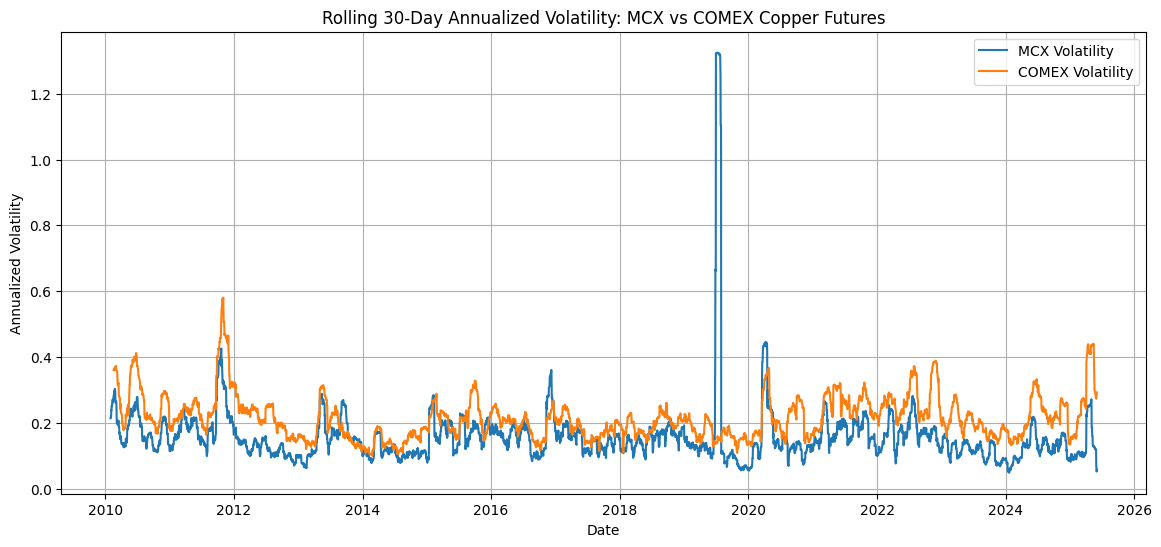

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# For MCX df (assuming df is already loaded with 'Date' and 'Avg_Price')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Log returns for MCX
df['Log_Returns'] = np.log(df['Avg_Price'] / df['Avg_Price'].shift(1))

# Average trading days per year for MCX
df['Year'] = df['Date'].dt.year
avg_trading_days_mcx = df.groupby('Year')['Date'].nunique().mean()

# Rolling 30-day std dev of log returns for MCX
rolling_std_mcx = df['Log_Returns'].rolling(window=30).std()

# Annualized volatility for MCX
df['Volatility_30d'] = rolling_std_mcx * np.sqrt(avg_trading_days_mcx)

# Normalized price for MCX
df['Normalized_Price'] = df['Avg_Price'] / df['Avg_Price'].iloc[0]

# For COMEX df_comex (assuming already loaded with 'Date' and 'Close_Price')
df_comex['Date'] = pd.to_datetime(df_comex['Date'])
df_comex = df_comex.sort_values('Date')

# Log returns for COMEX
df_comex['Log_Returns'] = np.log(df_comex['Close_Price'] / df_comex['Close_Price'].shift(1))

# Average trading days per year for COMEX
df_comex['Year'] = df_comex['Date'].dt.year
avg_trading_days_comex = df_comex.groupby('Year')['Date'].nunique().mean()

# Rolling 30-day std dev of log returns for COMEX
rolling_std_comex = df_comex['Log_Returns'].rolling(window=30).std()

# Annualized volatility for COMEX
df_comex['Volatility_30d'] = rolling_std_comex * np.sqrt(avg_trading_days_comex)

# Normalized price for COMEX
df_comex['Normalized_Price'] = df_comex['Close_Price'] / df_comex['Close_Price'].iloc[0]

# Plot rolling volatilities together
plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Volatility_30d', data=df, label='MCX Volatility')
sns.lineplot(x='Date', y='Volatility_30d', data=df_comex, label='COMEX Volatility')

plt.title('Rolling 30-Day Annualized Volatility: MCX vs COMEX Copper Futures')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True)
plt.show()


Correlation of daily log returns between MCX and COMEX copper futures: 0.5780


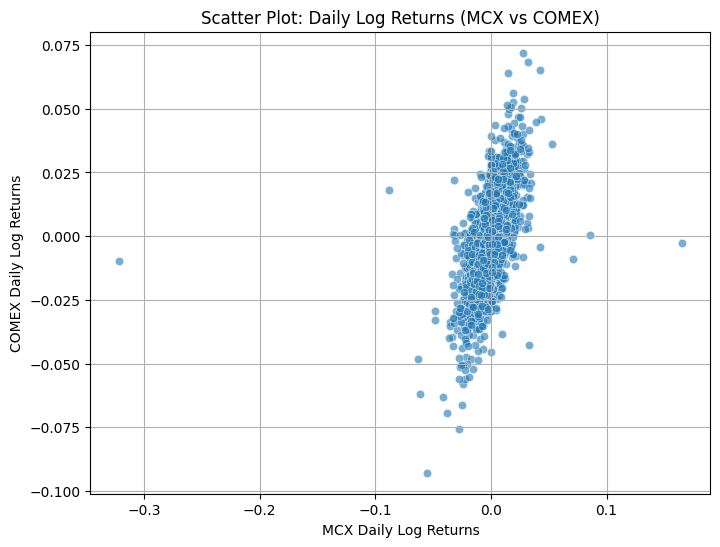

In [ ]:
df['Log_Returns'] = np.log(df['Avg_Price'] / df['Avg_Price'].shift(1))
df_comex['Log_Returns'] = np.log(df_comex['Close_Price'] / df_comex['Close_Price'].shift(1))

df_returns = pd.merge(
    df[['Date', 'Log_Returns']],
    df_comex[['Date', 'Log_Returns']],
    on='Date',
    how='inner',
    suffixes=('_MCX', '_COMEX')
)

df_returns.dropna(inplace=True)

correlation = df_returns['Log_Returns_MCX'].corr(df_returns['Log_Returns_COMEX'])
print(f"Correlation of daily log returns between MCX and COMEX copper futures: {correlation:.4f}")

# Plot scatter
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Log_Returns_MCX', y='Log_Returns_COMEX', data=df_returns, alpha=0.6)
plt.title('Scatter Plot: Daily Log Returns (MCX vs COMEX)')
plt.xlabel('MCX Daily Log Returns')
plt.ylabel('COMEX Daily Log Returns')
plt.grid(True)
plt.show()


When COMEX copper prices move up or down, MCX copper tends to move in the same direction about 57% of the time in a linear sense.

In [ ]:
import yfinance as yf
import pandas as pd

# Define ticker symbols
tickers = {
    'Freeport-McMoRan': 'FCX',
    'BHP Group': 'BHP',
    'Southern Copper': 'SCCO',
    'Glencore': 'GLEN.L',
    'Zijin Mining (HK)': '2899.HK',
    'Zijin Mining (Shanghai)': '601899.SS',
    'Anglo American': 'AAL.L',
    'KGHM Polska': 'KGH.WA',
    'Antofagasta': 'ANTO.L',
    'First Quantum': 'FM.TO',
    'Hindustan Copper': 'HINDCOPPER.NS'
}

# Download full data
raw_data = yf.download(list(tickers.values()), start="2010-01-01", end="2025-06-03", group_by='ticker', auto_adjust=False)

# Create a dictionary to extract adjusted close for each
adj_close_dict = {}

for name, ticker in tickers.items():
    try:
        adj_close = raw_data[ticker]['Adj Close']
        adj_close.name = name
        adj_close_dict[name] = adj_close
    except Exception as e:
        print(f"Skipping {name} ({ticker}): {e}")

# Combine all into one DataFrame
adj_close_df = pd.DataFrame(adj_close_dict)

# Drop rows where all values are NaN
adj_close_df.dropna(how='all', inplace=True)

# Preview
print(adj_close_df.head())

# Save to CSV
adj_close_df.to_csv("copper_equity_adj_close_2010_2025.csv")


[*********************100%***********************]  11 of 11 completed


            Freeport-McMoRan  BHP Group  Southern Copper  Glencore  \
Date                                                                 
2010-01-01               NaN        NaN              NaN       NaN   
2010-01-04         30.208916  34.168194        21.912605       NaN   
2010-01-05         30.389893  34.172489        22.129000       NaN   
2010-01-06         31.602448  34.735001        22.848169       NaN   
2010-01-07         30.997972  34.430126        22.631781       NaN   

            Zijin Mining (HK)  Zijin Mining (Shanghai)  Anglo American  \
Date                                                                     
2010-01-01                NaN                      NaN             NaN   
2010-01-04           2.916587                 4.616903     2688.775391   
2010-01-05           3.242837                 4.712889     2732.948975   
2010-01-06           3.242837                 4.645699     2780.035400   
2010-01-07           3.183875                 4.564111     2761.1

Correlation matrix of daily returns:
                       Tesla     BYD     NIO   XPeng  Li Auto  Rivian  \
Tesla                1.0000  0.0945  0.2744  0.2107   0.1898  0.2522   
BYD                  0.0945  1.0000  0.1790  0.1964   0.2167  0.0304   
NIO                  0.2744  0.1790  1.0000  0.5553   0.5031  0.3224   
XPeng                0.2107  0.1964  0.5553  1.0000   0.7099  0.3576   
Li Auto              0.1898  0.2167  0.5031  0.7099   1.0000  0.2782   
Rivian               0.2522  0.0304  0.3224  0.3576   0.2782  1.0000   
Lucid Motors         0.2278  0.0487  0.2941  0.3029   0.2204  0.5303   
Volkswagen           0.2774  0.1393  0.2091  0.1388   0.1187  0.1500   
General Motors       0.3070  0.1090  0.2265  0.1665   0.1365  0.2128   
Hyundai Motor Group  0.0669  0.0336  0.0282  0.0286   0.0218  0.0123   

                     Lucid Motors  Volkswagen  General Motors  \
Tesla                      0.2278      0.2774          0.3070   
BYD                        0.0487      

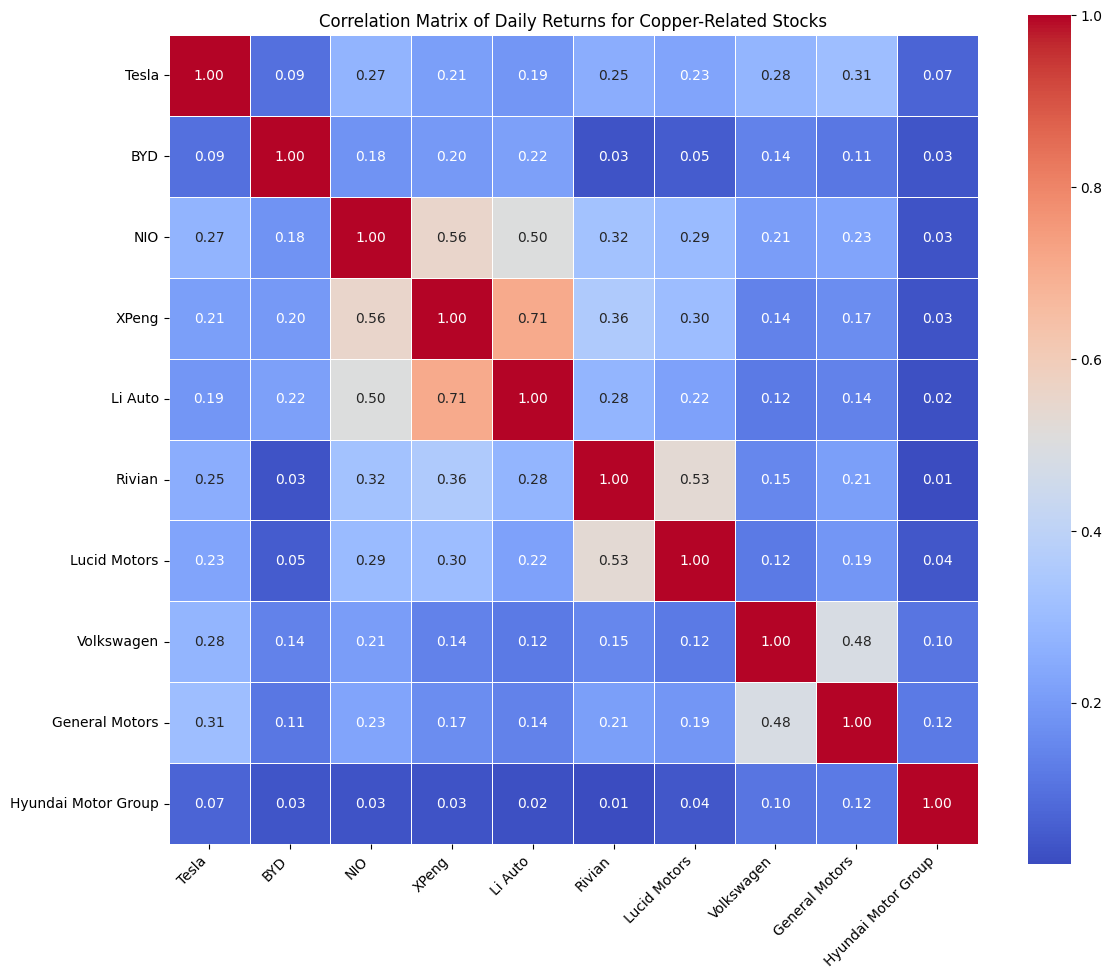

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract Close prices
close_prices = adj_close_df

# Forward-fill and back-fill missing values
close_prices = close_prices.ffill().bfill()

import numpy as np
returns = np.log(close_prices / close_prices.shift(1))

# Drop rows where all returns are NaN (but keep partial data)
returns = returns.dropna(how='all')

# Correlation matrix (this will use overlapping time periods)
correlation_matrix = returns.corr()

# Print correlation matrix
print("Correlation matrix of daily returns:\n", correlation_matrix.round(4))

# Plotting the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Matrix of Daily Returns for Copper-Related Stocks")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


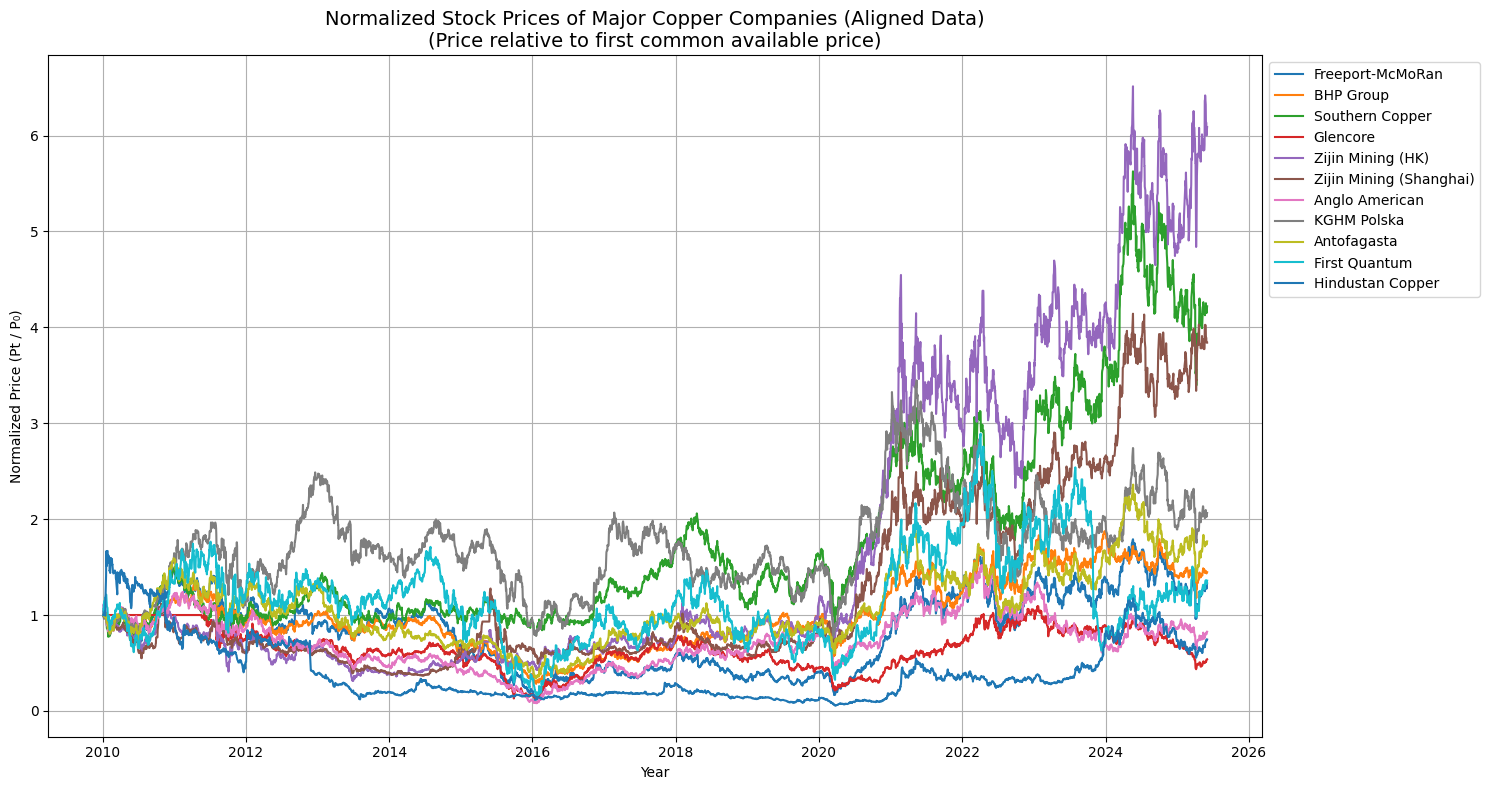

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Mapping of tickers to full company names
company_names = {
    'ANTO.L': 'Antofagasta',
    'BHP': 'BHP Group',
    'FCX': 'Freeport-McMoRan',
    'FM.TO': 'First Quantum Minerals',
    'GLEN.L': 'Glencore',
    'HINDCOPPER.NS': 'Hindustan Copper',
    'KGH.WA': 'KGHM Polska',
    'SCCO': 'Southern Copper Corp.',
    '601899.SS': 'Zijin Mining (Shanghai)',
    '2899.HK': 'Zijin Mining (HK)',
    'AAL.L': 'Anglo American'
}

# Step 1: Use correct close price data
close_prices = adj_close_df  # This should be your DataFrame with adjusted close prices

# Step 2: Forward-fill and back-fill missing values
close_prices = close_prices.ffill().bfill()

# Step 3: Calculate daily returns
returns = close_prices.pct_change()

# Step 4: Drop rows with any NaNs to align the date range across all stocks
returns_aligned = returns.dropna(how='any')

# Step 5: Subset the price data to only the aligned dates
aligned_prices = close_prices.loc[returns_aligned.index]

# Step 6: Normalize prices using the aligned data
normalized_prices = aligned_prices / aligned_prices.iloc[0]

# Step 7: Rename columns for clarity
normalized_prices = normalized_prices.rename(columns={v: company_names.get(k, k) for k, v in company_names.items() if v in normalized_prices.columns})

# Step 8: Plot the aligned and normalized prices
plt.figure(figsize=(15, 8))

for company in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[company], label=company)

plt.title('Normalized Stock Prices of Major Copper Companies (Aligned Data)\n(Price relative to first common available price)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Normalized Price (Pt / P₀)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: Install fredapi (only once needed)
!pip install fredapi

# Step 2: Import Libraries
from fredapi import Fred
import pandas as pd
from datetime import datetime

# Step 3: Initialize FRED API
fred_api_key = 'cccc80d70d6a7bf16b4cf788297faaa2'
fred = Fred(api_key=fred_api_key)

# Step 4: Define Date Range and Series ID
start_date = datetime(2010, 1, 1)
end_date = datetime(2025, 6, 3)
indicator_id = 'PCOPPUSDM'  # Copper price in USD per metric ton

# Step 5: Get Data and Store in copper_df
copper_series = fred.get_series(indicator_id, observation_start=start_date, observation_end=end_date)
copper_series.name = 'Copper Price (USD/MT)'

copper_df = copper_series.to_frame()
copper_df.index.name = 'Date'
copper_df.dropna(inplace=True)

# Step 6: Save to CSV
copper_df.to_csv("copper_price_2010_2025.csv")
print("✅ Saved: copper_price_2010_2025.csv")

# Step 7: Preview (optional)
print(copper_df.head())

✅ Saved: copper_price_2010_2025.csv
            Copper Price (USD/MT)
Date                             
2010-01-01            7367.375000
2010-02-01            6867.675000
2010-03-01            7466.934783
2010-04-01            7729.837500
2010-05-01            6843.157895



📊 Correlation of Mining Company Daily Returns with Copper Daily Returns:

KGHM Polska                0.327583
BHP Group                  0.272477
Anglo American             0.265680
Glencore                   0.225395
Antofagasta                0.223468
Zijin Mining (Shanghai)    0.214838
Zijin Mining (HK)          0.203949
Freeport-McMoRan           0.190302
First Quantum              0.146260
Southern Copper            0.130051
Hindustan Copper           0.087817
Name: Copper Price (USD/MT), dtype: float64


<ipython-input-57-b41b9b650038>:12: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  equity_returns = equity_df.pct_change().dropna()


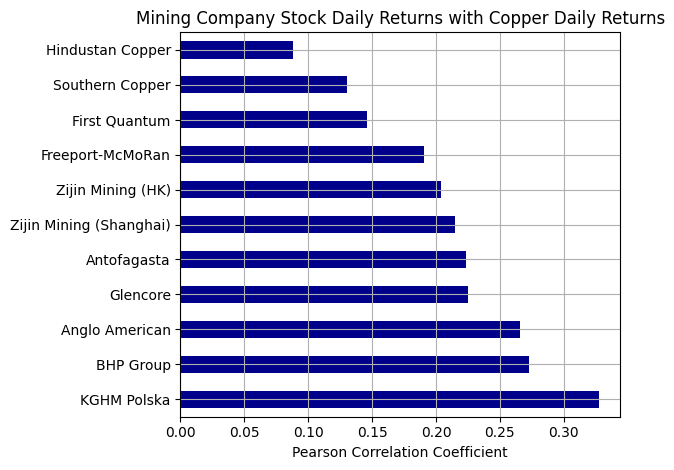

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load Equity Prices ---
equity_df = pd.read_csv("copper_equity_adj_close_2010_2025.csv", parse_dates=['Date'])
equity_df.set_index('Date', inplace=True)

# --- Assume copper_df is already loaded similarly ---
# e.g., copper_df = pd.read_csv("copper_price_2010_2025.csv", parse_dates=['Date']).set_index('Date')

# --- Calculate daily returns for both datasets ---
equity_returns = equity_df.pct_change().dropna()
copper_returns = copper_df.pct_change().dropna()

# --- Align dates ---
common_dates = equity_returns.index.intersection(copper_returns.index)
equity_returns = equity_returns.loc[common_dates]
copper_returns = copper_returns.loc[common_dates]

# --- Merge returns ---
merged_returns = equity_returns.join(copper_returns, how='inner')
merged_returns.dropna(inplace=True)

# --- Correlation Calculation on returns ---
correlation_with_copper = merged_returns.corr()['Copper Price (USD/MT)'].drop('Copper Price (USD/MT)')
correlation_with_copper = correlation_with_copper.sort_values(ascending=False)

# --- Display Results ---
print("\n📊 Correlation of Mining Company Daily Returns with Copper Daily Returns:\n")
print(correlation_with_copper)

# --- Optional: Bar Plot ---
correlation_with_copper.plot(kind='barh', color='darkblue')
plt.title("Mining Company Stock Daily Returns with Copper Daily Returns")
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.grid(True)
plt.show()


[*********************100%***********************]  10 of 10 completed


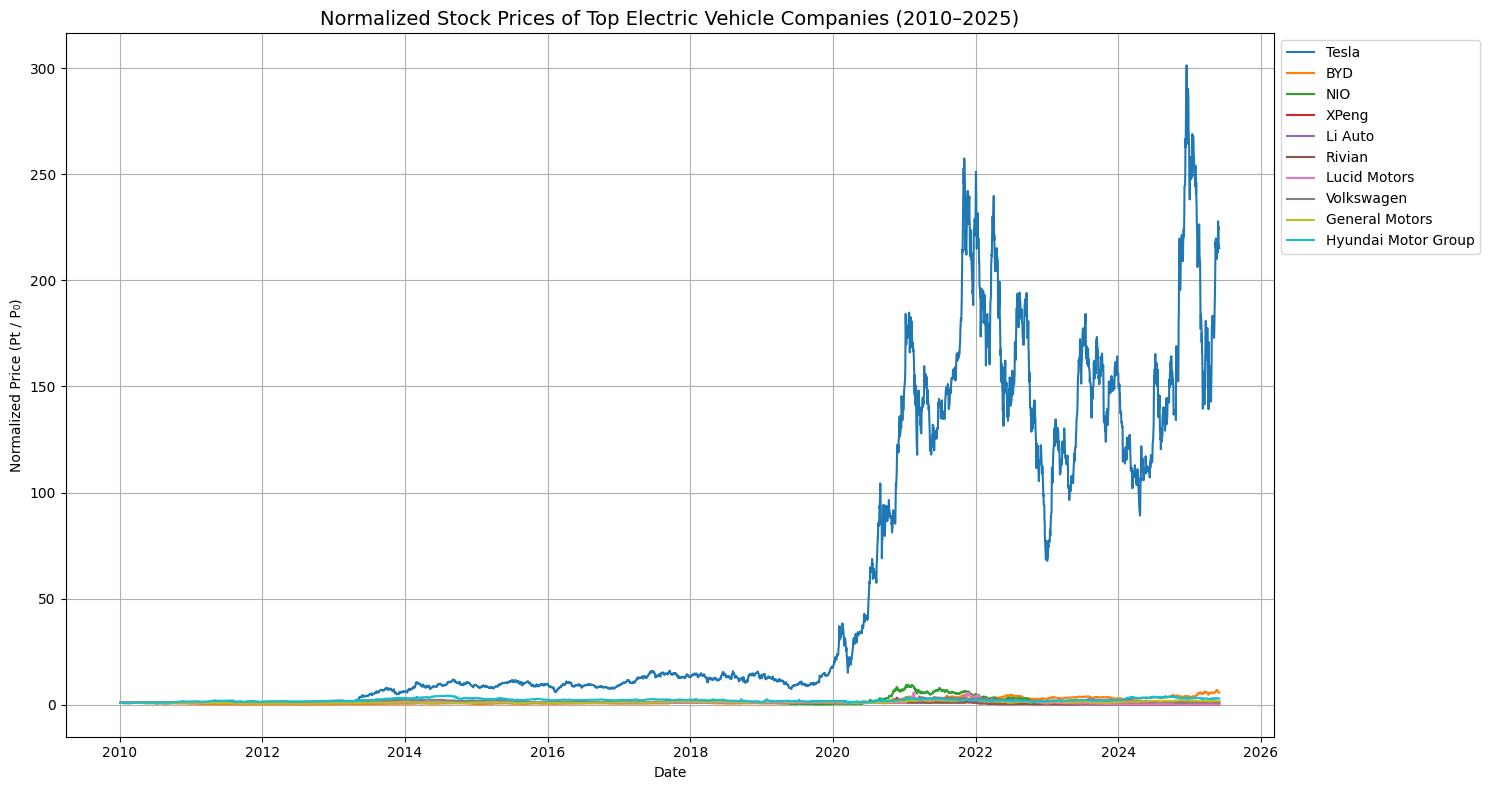

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Define EV company tickers and names
ev_tickers = {
    'TSLA': 'Tesla',
    '1211.HK': 'BYD',
    'NIO': 'NIO',
    'XPEV': 'XPeng',
    'LI': 'Li Auto',
    'RIVN': 'Rivian',
    'LCID': 'Lucid Motors',
    'VWAGY': 'Volkswagen',
    'GM': 'General Motors',
    'HYMTF': 'Hyundai Motor Group'
}

# Download adjusted close price data from 2010 to 2025 (adjust dates as needed)
raw_data = yf.download(list(ev_tickers.keys()), start="2010-01-01", end="2025-06-03", group_by='ticker', auto_adjust=True)

# Extract adjusted close prices into a DataFrame
adj_close_dict = {}
for ticker, name in ev_tickers.items():
    try:
        # Some tickers like VWAGY might not have detailed grouped data, handle accordingly
        if ticker in raw_data.columns.levels[0]:
            adj_close = raw_data[ticker]['Close']
        else:
            adj_close = raw_data['Close'] if 'Close' in raw_data.columns else raw_data[ticker]['Close']
        adj_close.name = name
        adj_close_dict[name] = adj_close
    except Exception as e:
        print(f"Skipping {name} ({ticker}): {e}")

adj_close_df = pd.DataFrame(adj_close_dict)

# Forward-fill and back-fill missing data
adj_close_df = adj_close_df.ffill().bfill()

# Calculate daily returns
returns = adj_close_df.pct_change()

# Drop rows with NaNs to align dates
returns_aligned = returns.dropna(how='any')

# Align prices on same date range
aligned_prices = adj_close_df.loc[returns_aligned.index]

# Normalize prices relative to first price
normalized_prices = aligned_prices / aligned_prices.iloc[0]

# Plot normalized prices
plt.figure(figsize=(15, 8))
for company in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[company], label=company)

plt.title('Normalized Stock Prices of Top Electric Vehicle Companies (2010–2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Price (Pt / P₀)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Step 1: Make sure date indices are in datetime format
copper_df.index = pd.to_datetime(copper_df.index)
adj_close_df.index = pd.to_datetime(adj_close_df.index)

# Step 2: Forward-fill and back-fill missing values
adj_close_df = adj_close_df.ffill().bfill()
copper_df = copper_df.ffill().bfill()

# Step 3: Align both datasets to common date range
common_dates = adj_close_df.index.intersection(copper_df.index)
adj_close_aligned = adj_close_df.loc[common_dates]
copper_aligned = copper_df.loc[common_dates]

# Step 4: Calculate daily returns
adj_returns = adj_close_aligned.pct_change().dropna()
copper_returns = copper_aligned.pct_change().dropna()

# Step 5: Align returns again (after dropna)
common_return_dates = adj_returns.index.intersection(copper_returns.index)
adj_returns = adj_returns.loc[common_return_dates]
copper_returns = copper_returns.loc[common_return_dates]

# Step 6: Combine into single DataFrame
combined_returns = pd.concat([adj_returns, copper_returns], axis=1)

# Step 7: Correlation matrix
corr_matrix = combined_returns.corr()

# Step 8: Extract correlation of each EV company with copper
copper_col_name = copper_returns.columns[0]  # e.g., 'Copper Price (USD/MT)'
correlation_with_copper = corr_matrix[copper_col_name].drop(copper_col_name)

# Step 9: Display results
print("\n📊 Correlation of EV Company Daily Returns with Copper Daily Returns:\n")
print(correlation_with_copper.sort_values(ascending=False))



📊 Correlation of EV Company Daily Returns with Copper Daily Returns:

General Motors         0.427967
Volkswagen             0.383560
Hyundai Motor Group    0.246307
BYD                    0.204737
NIO                    0.161188
Lucid Motors           0.137118
XPeng                  0.122151
Li Auto                0.094588
Tesla                  0.075721
Rivian                -0.016002
Name: Copper Price (USD/MT), dtype: float64


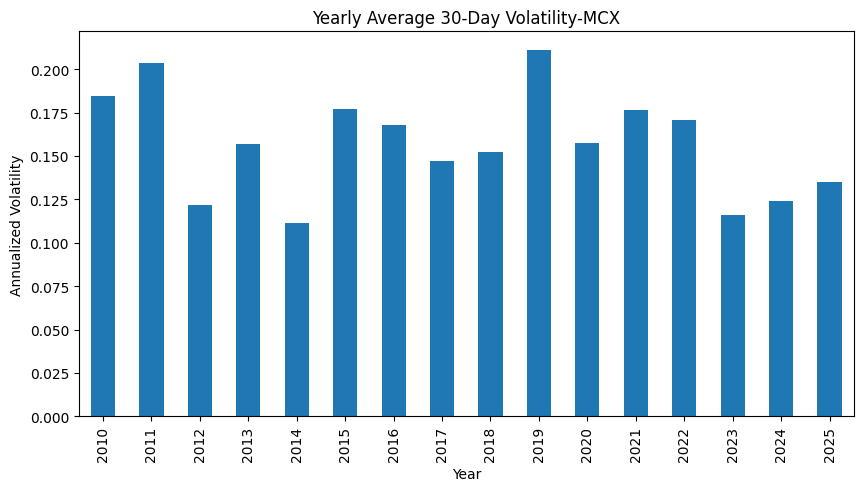

In [ ]:
# Yearly average volatility
yearly_volatility = df.groupby('Year')['Volatility_30d'].mean()
yearly_volatility.plot(kind='bar', figsize=(10,5), title='Yearly Average 30-Day Volatility-MCX')
plt.ylabel('Annualized Volatility')
plt.show()


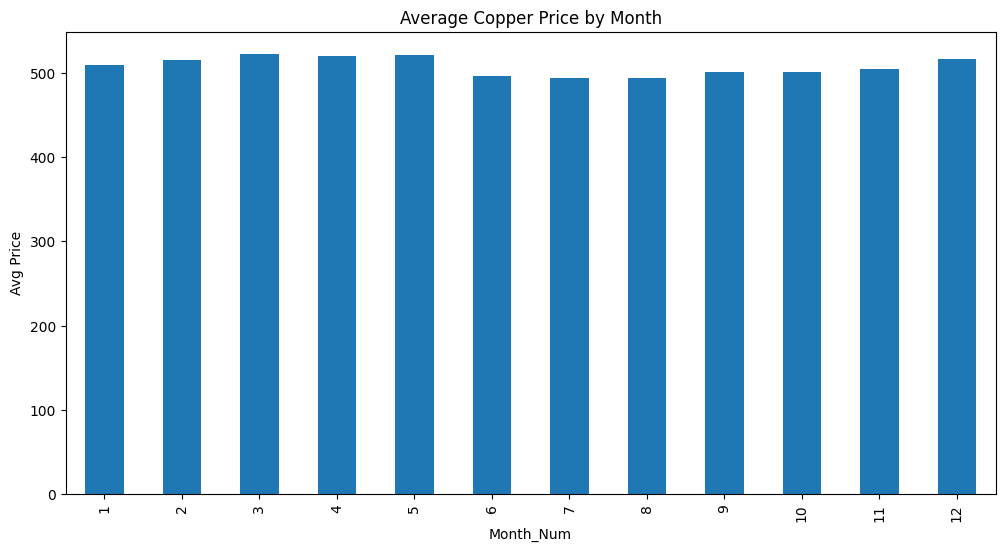

In [ ]:
df['Month_Num'] = df['Date'].dt.month
monthly_avg_price = df.groupby('Month_Num')['Avg_Price'].mean()

monthly_avg_price.plot(kind='bar', figsize=(12,6), title='Average Copper Price by Month')
plt.ylabel('Avg Price')
plt.show()
